In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

In [2]:
df = pd.read_csv("GEFCom2014_prepared.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "hour"]).reset_index(drop=True)

# Ensure embedding compatibility
df["hour"] = df["hour"].astype(int)
df["day_of_week"] = df["day_of_week"].astype(int)
df["is_weekend"] = df["is_weekend"].astype(int)

In [3]:
load_features = ['load', 'lag_1', 'lag_24', 'load_roll_mean_24', 'load_roll_std_24']

temp_features = [
    'temp', 'temp_lag_1', 'temp_lag_24',
    'temp_roll_mean_24', 'temp_roll_std_24',
    'CDD', 'HDD'
]

calendar_features = ['hour', 'day_of_week', 'month', 'is_weekend']

zone_cols = [
    "zone_residential",
    "zone_commercial",
    "zone_industrial"
]

target_cols = zone_cols + ["load"]

In [4]:
df["hour"] = df["hour"].astype(int) % 24
df["day_of_week"] = df["day_of_week"].astype(int) % 7
df["month"] = df["month"].astype(int) - 1
df["is_weekend"] = df["is_weekend"].astype(int)

if "sum_zones" in df.columns:
    df = df.drop(columns=["sum_zones"])

In [5]:
SEQ_LEN = 24

class MultiModalDataset(Dataset):

    def __init__(self, df):

        self.load_data = df[load_features].values.astype(np.float32)
        self.temp_data = df[temp_features].values.astype(np.float32)
        self.cal_data = df[calendar_features].values.astype(np.int64)
        self.targets = df[target_cols].values.astype(np.float32)

    def __len__(self):

        return len(self.load_data) - SEQ_LEN

    def __getitem__(self, idx):

        Xl = self.load_data[idx:idx+SEQ_LEN]
        Xt = self.temp_data[idx:idx+SEQ_LEN]
        Xc = self.cal_data[idx:idx+SEQ_LEN]

        y = self.targets[idx+SEQ_LEN]

        return (
            torch.tensor(Xl),
            torch.tensor(Xt),
            torch.tensor(Xc),
            torch.tensor(y)
        )

# ==========================================
# TRAIN-TEST SPLIT
# ==========================================

split_idx = int(0.8 * len(df))

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

# ==========================================
# NORMALIZATION
# ==========================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scale_cols = (
    load_features +
    temp_features +
    target_cols
)

train_df[scale_cols] = scaler.fit_transform(
    train_df[scale_cols]
)

test_df[scale_cols] = scaler.transform(
    test_df[scale_cols]
)

# ==========================================
# DATASETS + DATALOADERS
# ==========================================

train_ds = MultiModalDataset(train_df)
test_ds = MultiModalDataset(test_df)

train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False
)

In [6]:
class QuantileModel(nn.Module):
    def __init__(self, num_targets, quantiles):
        super().__init__()
        self.quantiles = quantiles

        self.lstm = nn.LSTM(len(load_features), 64, batch_first=True)

        self.temp_mlp = nn.Sequential(
            nn.Linear(len(temp_features), 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.hour_emb = nn.Embedding(24, 8)
        self.day_emb = nn.Embedding(7, 4)
        self.month_emb = nn.Embedding(12, 4)
        self.weekend_emb = nn.Embedding(2, 2)

        fusion_size = 64 + 32 + 18

        self.fc = nn.Sequential(
            nn.Linear(fusion_size, 64),
            nn.ReLU(),
            nn.Linear(64, num_targets * len(quantiles))
        )

    def forward(self, Xl, Xt, Xc):
        _, (h, _) = self.lstm(Xl)
        load_out = h[-1]

        temp_out = self.temp_mlp(Xt[:, -1, :])

        hour = self.hour_emb(Xc[:, -1, 0])
        day = self.day_emb(Xc[:, -1, 1])
        month = self.month_emb(Xc[:, -1, 2])
        weekend = self.weekend_emb(Xc[:, -1, 3])

        cal_out = torch.cat([hour, day, month, weekend], dim=1)

        fused = torch.cat([load_out, temp_out, cal_out], dim=1)

        out = self.fc(fused)

        return out.view(out.size(0), len(target_cols), len(self.quantiles))

In [7]:
def quantile_loss(preds, target, quantiles):
    loss = 0
    for i, q in enumerate(quantiles):
        errors = target - preds[:, :, i]
        loss += torch.mean(torch.max((q - 1) * errors, q * errors))
    return loss

In [22]:
quantiles = [0.1, 0.5, 0.9]

model = QuantileModel(
    num_targets=len(target_cols),
    quantiles=quantiles
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [23]:
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for Xl, Xt, Xc, y in train_loader:
        Xl, Xt, Xc, y = Xl.to(device), Xt.to(device), Xc.to(device), y.to(device)

        optimizer.zero_grad()

        preds = model(Xl, Xt, Xc)

        loss = quantile_loss(preds, y, quantiles)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f}")

Epoch 1 | Loss: 62.4696
Epoch 2 | Loss: 36.0402
Epoch 3 | Loss: 25.6202
Epoch 4 | Loss: 22.5625
Epoch 5 | Loss: 20.7345
Epoch 6 | Loss: 20.3842
Epoch 7 | Loss: 19.4838
Epoch 8 | Loss: 18.1397
Epoch 9 | Loss: 18.4975
Epoch 10 | Loss: 17.8882
Epoch 11 | Loss: 18.0425
Epoch 12 | Loss: 18.7249
Epoch 13 | Loss: 17.8398
Epoch 14 | Loss: 17.4698
Epoch 15 | Loss: 17.3954
Epoch 16 | Loss: 17.1529
Epoch 17 | Loss: 17.0639
Epoch 18 | Loss: 16.9454
Epoch 19 | Loss: 16.6260
Epoch 20 | Loss: 16.5501


In [24]:
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for Xl, Xt, Xc, y in test_loader:
        Xl, Xt, Xc = Xl.to(device), Xt.to(device), Xc.to(device)

        preds = model(Xl, Xt, Xc).cpu().numpy()

        all_preds.append(preds)
        all_true.append(y.numpy())

all_preds = np.vstack(all_preds)
all_true = np.vstack(all_true)

In [25]:
results = pd.DataFrame({

    "Metric": [

        "Median Forecast MAE",
        "Median Forecast RMSE",
        "Prediction Interval Coverage (P10–P90)",
        "Average Prediction Interval Width",
        "Average P10 Forecast",
        "Average P50 Forecast",
        "Average P90 Forecast"

    ],

    "Symbol": [

        "MAE(P50)",
        "RMSE(P50)",
        "PICP",
        "MPIW",
        "Mean(P10)",
        "Mean(P50)",
        "Mean(P90)"

    ],

    "Value": [

        round(mae, 6),

        round(
            np.sqrt(np.mean((actual - p50) ** 2)),
            6
        ),

        round(coverage, 6),

        round(width, 6),

        round(np.mean(p10), 6),
        round(np.mean(p50), 6),
        round(np.mean(p90), 6)

    ]

})

print(results)

results.to_csv(
    "outputs/tables/rq3_results.csv",
    index=False
)

                                   Metric     Symbol     Value
0                     Median Forecast MAE   MAE(P50)  0.012526
1                    Median Forecast RMSE  RMSE(P50)  0.015654
2  Prediction Interval Coverage (P10–P90)       PICP  0.697442
3       Average Prediction Interval Width       MPIW  0.034353
4                    Average P10 Forecast  Mean(P10)  0.394132
5                    Average P50 Forecast  Mean(P50)  0.407032
6                    Average P90 Forecast  Mean(P90)  0.428485


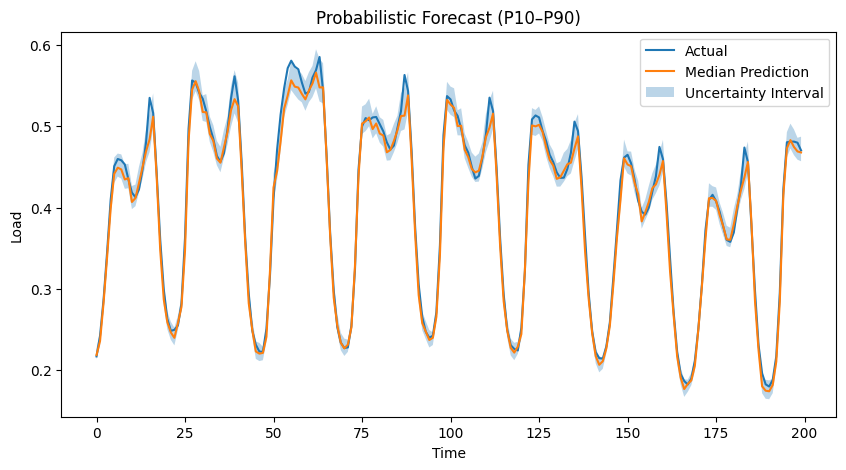

In [29]:
plt.figure(figsize=(10,5))

plt.plot(actual[:200], label="Actual")
plt.plot(p50[:200], label="Median Prediction")

plt.fill_between(
    range(200),
    p10[:200],
    p90[:200],
    alpha=0.3,
    label="Uncertainty Interval"
)

plt.legend()
plt.title("Probabilistic Forecast (P10–P90)")
plt.xlabel("Time")
plt.ylabel("Load")

plt.savefig("outputs/figures/rq3_uncertainty_plot.pdf")
plt.show()

In [13]:
df.describe()

,date,hour,load,temp,day_of_week,month,day,is_weekend,lag_1,lag_24,...,zone_commercial,zone_industrial,temp_lag_1,temp_lag_24,temp_roll_mean_24,temp_roll_std_24,CDD,HDD,load_roll_mean_24,load_roll_std_24
count,78696,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,...,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000
mean,2010-07-06 00:00:00,11.500000,3307.491334,47.631260,2.998170,5.536749,15.756023,0.285453,3307.486569,3307.397403,...,1149.434537,826.778468,47.631320,47.632434,47.631847,5.538399,1.659453,19.028193,3307.450591,499.484333
min,2006-01-09 00:00:00,0.000000,1811.000000,-18.000000,0.000000,0.000000,1.000000,0.000000,1811.000000,1811.000000,...,591.841260,447.913303,-18.000000,-18.000000,-4.722222,0.386726,0.000000,0.000000,2517.750000,245.775481
25%,2008-04-07 00:00:00,5.750000,2845.000000,33.000000,1.000000,3.000000,8.000000,0.000000,2845.000000,2845.000000,...,958.339085,709.420888,33.000000,33.000000,33.440972,3.577029,0.000000,2.000000,3098.291667,442.717591
50%,2010-07-06 00:00:00,11.500000,3381.000000,48.666667,3.000000,6.000000,16.000000,0.000000,3381.000000,3381.000000,...,1109.839550,839.425749,48.666667,48.666667,48.986111,5.350328,0.000000,16.333333,3270.833333,489.756956
75%,2012-10-03 00:00:00,17.250000,3708.000000,63.000000,5.000000,9.000000,23.000000,1.000000,3708.000000,3708.000000,...,1325.988696,929.678228,63.000000,63.000000,63.694444,7.290291,0.000000,32.000000,3494.583333,541.814482
max,2014-12-31 00:00:00,23.000000,5506.000000,97.000000,6.000000,11.000000,31.000000,1.000000,5506.000000,5506.000000,...,2130.101126,1456.773056,97.000000,97.000000,87.888889,16.138266,32.000000,83.000000,4664.958333,906.468397
std,NaN,6.922231,579.850915,19.187866,2.000164,3.442014,8.792204,0.451633,579.852148,579.824222,...,252.862684,149.254267,19.187773,19.186085,18.238666,2.522301,4.136584,16.967890,300.123473,85.703217
